In [313]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from helper_functions import E_to_speed
from pade.pade import pade

# constants
c = 299792458
q_e =  1.60217646e-19
h_bar = 1.054571817e-34
epsilon_0 = 8.8541878188e-12

# lattice constant
a = 426e-9

In [ ]:
conversion_factor = a**(-3/2)/np.sqrt(epsilon_0)
# conversion_factor = np.sqrt(h_bar*c/epsilon_0)/a**2
print(conversion_factor)

1208679722663082.2


In [334]:
DIFF = h5py.File("normalized-out/diff_PML_a36_r245.hdf5")
# EMPTY = h5py.File("Normalization-out/empty_PML_a36-ex.hdf5")
E_ind = DIFF['ex']
E_ind = E_ind[()]*conversion_factor # convert E in MEEP units to SI
E_ind

array([[ 3.91828438e-05, -4.50649091e-05, -1.21862878e-04, ...,
        -3.68015897e-05, -2.87346806e-05, -3.03902040e-05],
       [ 4.13038740e-05,  7.16048103e-05,  4.79345192e-05, ...,
        -1.87075295e-05, -2.49668213e-05, -3.50495078e-05],
       [-1.10662777e-05,  3.62234163e-05,  7.08528551e-05, ...,
        -3.10111580e-05, -3.17158441e-05, -2.47311029e-05],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         2.07340285e-05,  1.67458961e-05,  1.44421306e-05],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         4.24959857e-05,  4.72113584e-05,  6.66774105e-05],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         1.07123762e-04,  8.20142576e-05,  5.68463325e-05]],
      shape=(866, 3152))

In [335]:
distance = 36*a # 28 unit cells with a width of 426 nm
velocity = E_to_speed(1e5)*c
Time = distance/velocity
resolution = distance/E_ind.shape[0]
N = E_ind.shape[1] # length of time or frequency array (2451)
dt = Time/(N-1)
t = np.linspace(0,Time,N)
freqs = np.arange(0,int(N/2)+1)*2*np.pi/Time
resolution

1.7709006928406468e-08

In [336]:
# FFT # Because of symmetry -> only keep first half corresponding to positive frequencies
E_hat = np.fft.fft(E_ind[()]).T[:int(N/2)]
E_hat = E_hat*dt
freqs = (np.fft.fftfreq(N,dt)*2*np.pi)[:int(N/2)] # corresponding angular frequencies (i.e. omega = 2pi k/Ndt, (k is in cylces per N))

In [337]:
freqs

array([0.00000000e+00, 6.73141251e+13, 1.34628250e+14, ...,
       1.05885119e+17, 1.05952433e+17, 1.06019747e+17], shape=(1576,))

In [338]:
# pade FT
w_max = 2*q_e/h_bar
freqs = np.linspace(0,w_max,N)
E_hat = np.zeros((E_ind.shape[0],len(freqs)), dtype='complex128')

for i, x in enumerate(E_ind):
    E_hat[i], freqs = pade(t,x,read_freq=freqs,baseline='none')
E_hat = E_hat.T

In [355]:
np.sum(E_hat.T[:-6])

np.complex128(153.24981649835817+60.276446076704715j)

In [356]:
E_hat = E_hat.T[:-6].T

In [357]:
Gamma = np.zeros(len(freqs))
for i_omega, Ex_omega in enumerate(E_hat): # enumerate over the series of Ex(x)'s where each list corresponds to Ex(x) values for a different omega
    omega = freqs[i_omega]
    for px, Ex_x in enumerate(Ex_omega): # for given omega, iterate over all pixels in the Ex series, we need to integrate over x
        dx = resolution
        x = dx*(px+0.5) # take the center of the pixel to represent the position of the electron

        # Accumulate the integral values
        # Gamma[i_omega] += ( Ex_x.real*np.cos(omega*x/velocity) - Ex_x.imag*np.sin(omega*x/velocity) )*dx
        Gamma[i_omega] += ( Ex_x*np.exp((omega*x/velocity)*1j) ).real*dx
    Gamma[i_omega] = (q_e/(np.pi*h_bar*omega))*Gamma[i_omega]
Gamma[0] = 0

/tmp/ipykernel_116258/4125710860.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  Gamma[i_omega] = (q_e/(np.pi*h_bar*omega))*Gamma[i_omega]


In [358]:
# Gamma[1] = 0

Text(0, 0.5, 'Loss probability %')

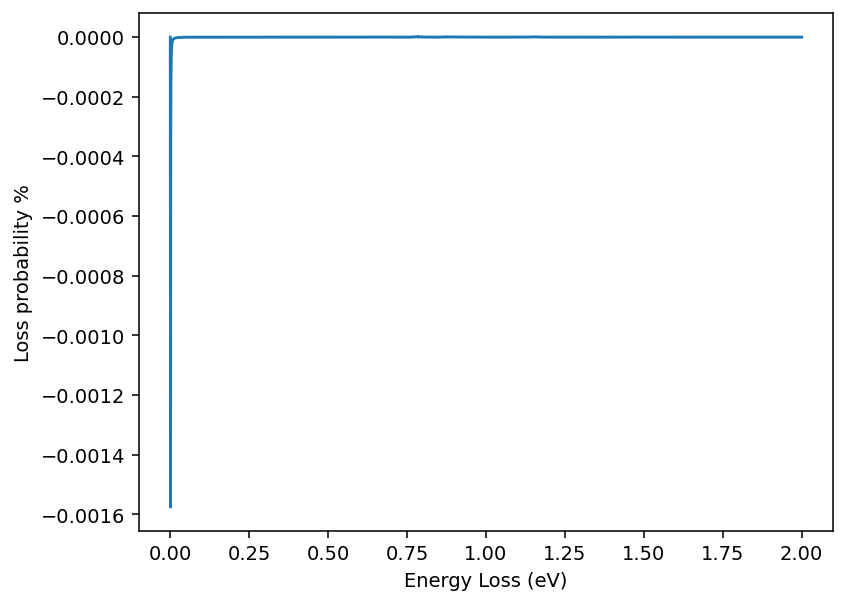

In [359]:
plt.figure(dpi=140)
# plt.plot(freqs[:int(N/2)+1]*h_bar/q_e, Gamma[:int(N/2)+1]*100)
plt.plot(freqs*h_bar/q_e, Gamma*100)
# plt.hlines(y=0,xmin=0,xmax=6, ls='--', lw=1, color='grey')
plt.xlabel('Energy Loss (eV)')
plt.ylabel('Loss probability %')
# plt.xlim((0,2))

## Convolution with gaussian

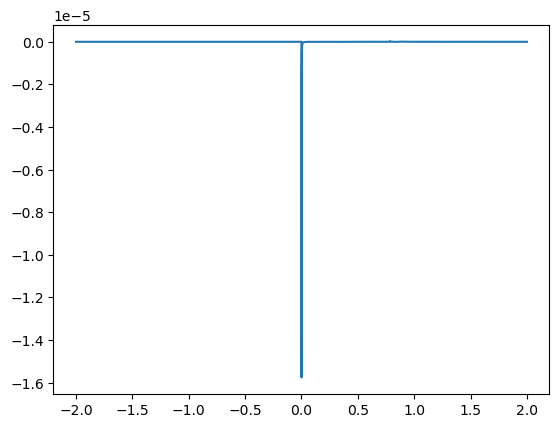

In [360]:
Gamma_ext = np.append(np.zeros(len(freqs)-1), Gamma)
freqs_ext = np.append((freqs[1:]*-1)[::-1],freqs)
plt.plot(freqs_ext*h_bar/q_e, Gamma_ext)

In [361]:
def gaussian(x, mu, sigma):
    return 1/np.sqrt(2*np.pi*sigma**2)*np.exp(-(x-mu)**2/(2*sigma**2))

In [362]:
FWHM = 30e-3 # eV  # = 2*np.sqrt(2*np.log(2)) * sigma
sigma = FWHM/(2*np.sqrt(2*np.log(2)))

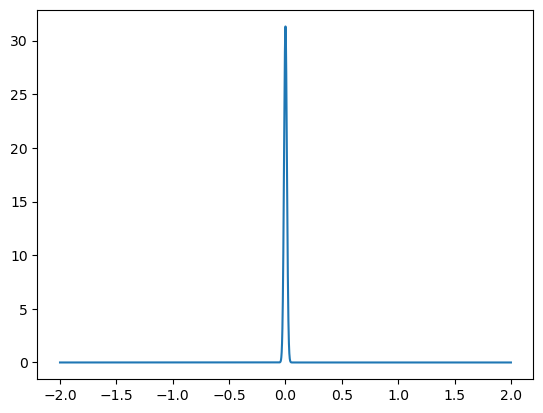

In [363]:
t = np.linspace(freqs[0],freqs[-1],len(freqs))
scale = t[-1]/(freqs[-1]*h_bar/q_e)
gauss = gaussian(freqs_ext*h_bar/q_e, 0, sigma)
plt.plot(freqs_ext*h_bar/q_e, gauss)

In [364]:
Gamma_c = np.convolve(Gamma_ext, gauss, mode='same')

(-0.25, 2.0)

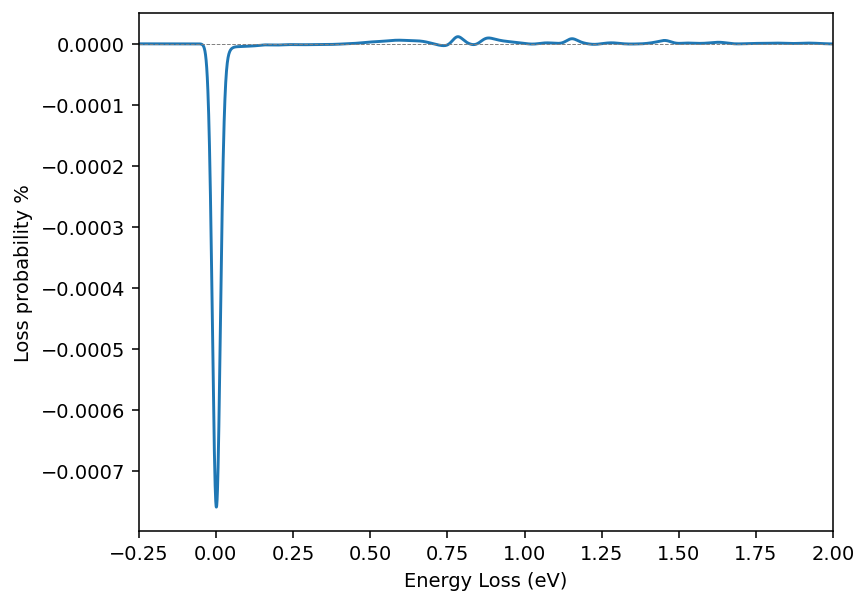

In [365]:
plt.figure(dpi=140)
plt.plot(freqs_ext*h_bar/q_e, Gamma_c)
plt.hlines(y=0,xmin=-0.25,xmax=2, ls='--', lw=0.5, color='grey')
plt.xlabel('Energy Loss (eV)')
plt.ylabel('Loss probability %')
plt.xlim((-0.25,2))
# plt.ylim(ymax=0.05)

(0.4, 1.05)

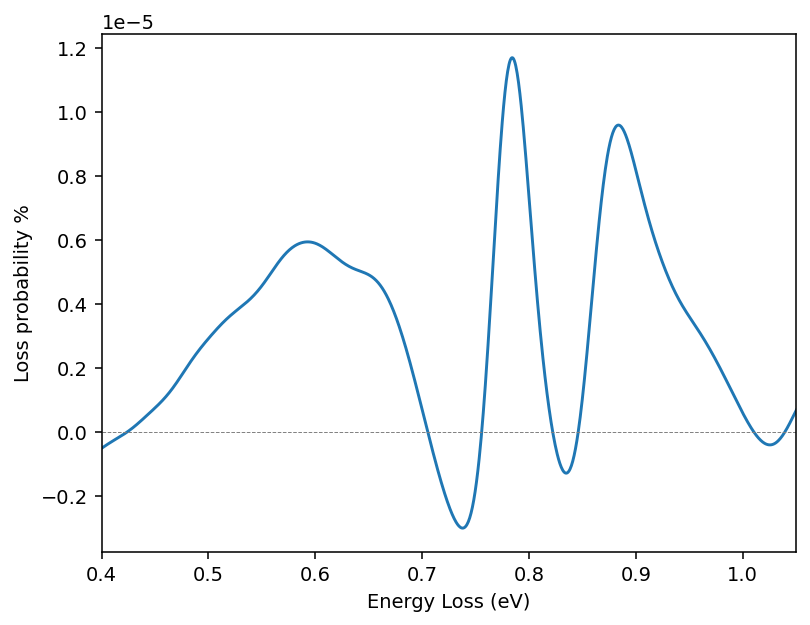

In [368]:
plt.figure(dpi=140)
plt.plot(freqs_ext[3500:]*h_bar/q_e, Gamma_c[3500:])
plt.hlines(y=0,xmin=0,xmax=2, ls='--', lw=0.5, color='grey')
plt.xlabel('Energy Loss (eV)')
plt.ylabel('Loss probability %')
plt.xlim((0.4,1.05))
# plt.ylim(ymin=-0.02,ymax=0.17)